In [1]:
import sys
from pathlib import Path
root = Path.cwd()
while root != root.parent:
    if (root / 'utils.py').exists():
        break
    root = root.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

In [2]:
from utils import cfg
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
application_train = pd.read_csv(cfg.get_train('application'))

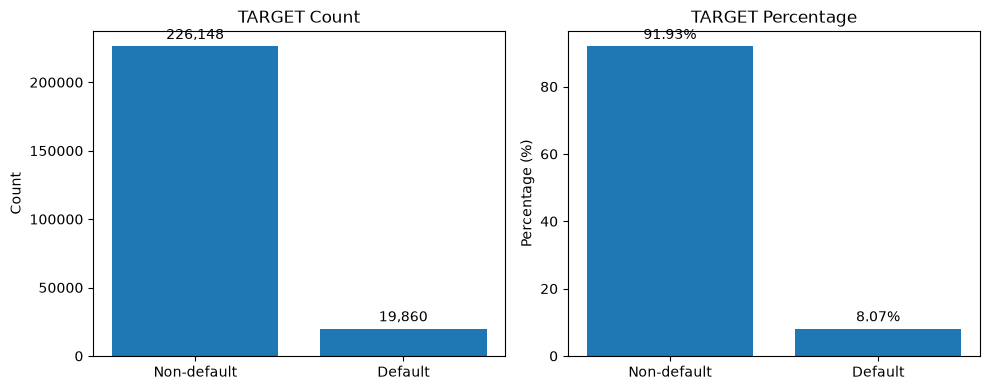

In [4]:
counts = application_train["TARGET"].value_counts().sort_index()
percentages = counts / counts.sum() * 100

labels = ["Non-default", "Default"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count
bars1 = axes[0].bar(labels, counts)
axes[0].bar_label(bars1, labels=[f"{x:,}" for x in counts], padding=3)

axes[0].set_title("TARGET Count")
axes[0].set_ylabel("Count")

# Percentage
bars2 = axes[1].bar(labels, percentages)
axes[1].bar_label(bars2, labels=[f"{x:.2f}%" for x in percentages], padding=3)

axes[1].set_title("TARGET Percentage")
axes[1].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

Data Imbalance: There are only 8.07% of the total loans that had actually been Defaulted.

- 91.9% loans were not Defaulted. Thus, Non-Defaulters will be our majority class.

- For imbalanced dataset, during building the model, we cannot feed the data as is to some algorithms, which are imbalance sensitive.

- Similar is the case with the Performance Metrics. For such a dataset, Accuracy is usually not the right metric as the Accuracy would generally be biased to majority class. We can use other metrics such as ROC-AUC Score, Gini, F1-Score, Confusion Matrix for better evaluation of model.

- One more important thing to note here is that there are very few people who actually default, and they tend to show some sort of different behaviour. Thus in such cases of Fraud, Default and Anamoly Detection, we need to focus on outliers too, and we cannot remove them, as they could be the differentiating factor between Defaulter and Non-Defaulter.